In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import torch

# higher-res plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
from transformers import GPT2Model,GPT2Tokenizer
gpt2 = GPT2Model.from_pretrained('gpt2')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
all_tokens_dict = tokenizer.get_vocab()

# get the Word Token Embeddings matrix
embeddings = gpt2.wte.weight.detach().numpy()

/home/robertcowher/anaconda3/envs/llm_course/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
unembeddings = embeddings.T
unembeddings_random = torch.rand_like(torch.from_numpy(unembeddings)).detach().numpy()

In [ ]:
# print(id(unembeddings))
# print(id(embeddings))

137973122907856
137974898267056


In [15]:
print(f"Embedding dimensions: {gpt2.config.n_embd}")
print(f"Vocab size: {gpt2.config.vocab_size}")
print(f"Size of embedding matrix: {embeddings.shape}")
print(f"Size of unembeddings matrix: {unembeddings.shape}")
print(f"Size of random unembeddings matrix: {unembeddings_random.shape}")

Embedding dimensions: 768
Vocab size: 50257
Size of embedding matrix: (50257, 768)
Size of unembeddings matrix: (768, 50257)
Size of random unembeddings matrix: (768, 50257)


In [19]:
def embed(token):
    token_idx = tokenizer.encode(token)[0]
    token_embeddings = embeddings[token_idx]

    return token_embeddings 

def unembed(token_embeddings):
    logits = token_embeddings @ embeddings.T
    predicted_token_idx = logits.argmax()
    predicted_token = tokenizer.decode([predicted_token_idx])

    return predicted_token


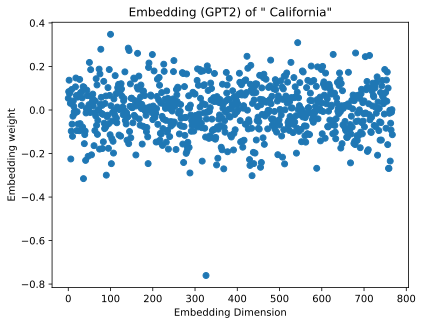

In [26]:
emb_california = embed(" California")

plt.title('Embedding (GPT2) of " California"')
plt.xlabel('Embedding Dimension')
plt.ylabel("Embedding weight")
plt.scatter(np.arange(len(emb_california)), emb_california)

In [32]:
logits = np.dot(emb_california, unembeddings)

print(tokenizer.decode([logits.argmax()]))

r_logits = np.dot(emb_california, unembeddings_random)

print(tokenizer.decode([r_logits.argmax()]))


California
 Trader


In [44]:
dp = np.dot(emb_california, unembeddings)

print(dp)

top10 = np.argsort(dp)[::-1][:10]

for i in top10:
    print(f'Dot product {dp[i]} for token {tokenizer.decode(i)}')

# top10 = np.argsort(dp[0])[::-1][:10]

# for i in top10:
#     print(i)

[2.1238046 2.4398541 2.7362309 ... 3.4226036 3.068024  2.4526982]
Dot product 10.136421203613281 for token California
Dot product 9.616878509521484 for token  California
Dot product 8.815817832946777 for token  Californ
Dot product 8.087570190429688 for token Calif
Dot product 7.718114376068115 for token  Calif
Dot product 7.359428405761719 for token  Nevada
Dot product 7.158401966094971 for token Arizona
Dot product 7.150633335113525 for token Colorado
Dot product 6.973984718322754 for token Florida
Dot product 6.911914348602295 for token Oregon


In [66]:
sent = ["husband"]

current_token = sent[0]

for i in range(10):
    emb = embed(current_token)
    
    dp = np.dot(emb, unembeddings)

    top10 = np.argsort(dp)[::-1][:10]

    next_token_idx = np.random.choice(top10)

    next_token = tokenizer.decode(next_token_idx)

    sent.append(next_token)

    current_token = next_token    

    # for i in top10:
    #     print(f'Dot product {dp[i]} for token {tokenizer.decode(i)}')

print(sent)





['husband', 'husband', 'wife', ' Wife', ' Bride', ' Mermaid', 'DragonMagazine', 'govtrack', 'channelAvailability', 'inventoryQuantity', 'ItemImage']
